# Model calibration: Effects of to 2,4D effects on *Discoglossus pictus* juveniles after pre-exposure to larvae

In [17]:
#using  Pkg; Pkg.instantiate() # if necessary, install dependencies

In [30]:
using DrWatson
@quickactivate "."

using DataFrames, DataFramesMeta, CSV 
using StatsPlots, Plots.Measures
default(leg = false)

using EcotoxSystems, AmphiDEB
include(srcdir("utils.jl"));

using Revise

const SAVETAG_LARVALFIT = "input/Discoglossus_larvae" # directory from which larval/metamorph parameters are loaded
const SAVETAG_JUVENILEFIT = "input/Discoglossus_juveniles" # directory from which juvenile/adult parameters are loaded
const SAVETAG_TKTDFIT = "Discoglossus_24D"
const SAVETAG = "Discoglossus_24D_Ugent_exp1"

using Revise

includet(scriptsdir("ModelFitting_Discoglossus_24D_Ugent_exp1.jl"))

In [19]:
using Pkg
Pkg.status("AmphiDEB") # show version of AmphiDEB used

Status `C:\Users\simon\Documents\AmphiDEBResearch\WP02_TKTD\Project.toml`
  [eee04faf] AmphiDEB v0.3.3 `https://github.com/simonhansul/amphideb.git#main`


In [20]:
Pkg.status("EcotoxSystems") # show version of EcotoxSystems used

Status `C:\Users\simon\Documents\AmphiDEBResearch\WP02_TKTD\Project.toml`
  [a070e96f] EcotoxSystems v0.2.3 `https://github.com/simonhansul/ecotoxsystems.jl#main`


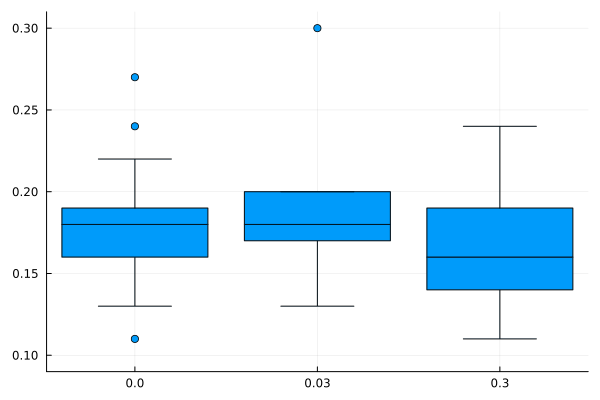

In [ ]:
data = load_data_exp1()

function plot_data_exp1()

end


@chain data[:juveniles] begin
    @subset(.!ismissing.(:weight))
    @subset(:treatment_bd .== "uninfected")
    @df _ groupedboxplot(
        string.(:treatment_24D), :weight, 
        ylim = (0.09, 0.31), 
        xlabel = "2,4-D pre-exposure (mg/L)", 
        ylabel = ""
    )
end